In [1]:
import os

for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks/data'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

gameWReview_02_path = "/content/drive/MyDrive/Colab Notebooks/data/gameWReview_02.csv"
processed_gameWReview_02_path = "/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview_02.csv"
steam_game_prediction_path = "/content/drive/MyDrive/Colab Notebooks/data/steam_game_prediction.csv"

/content/drive/MyDrive/Colab Notebooks/data/topSellerGameID.csv
/content/drive/MyDrive/Colab Notebooks/data/topSellerGames.csv
/content/drive/MyDrive/Colab Notebooks/data/topSellGameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/gameID.csv
/content/drive/MyDrive/Colab Notebooks/data/gameIDver02.csv
/content/drive/MyDrive/Colab Notebooks/data/games.csv
/content/drive/MyDrive/Colab Notebooks/data/games_02.csv
/content/drive/MyDrive/Colab Notebooks/data/gameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/gameWReview_02.csv
/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/steam_trainset.txt
/content/drive/MyDrive/Colab Notebooks/data/totalSellersWReview.csv
/content/drive/MyDrive/Colab Notebooks/data/processed_gameWReview_02.csv
/content/drive/MyDrive/Colab Notebooks/data/steam_game_prediction.csv


## data info
---
1. `appid` : 게임 아이디
2. `title` : 게임 이름
2. `releaseDate` : 출시 일자
3. `price` : 가격
4. `developer tier` : 개발자 등급*(팔로워 10만 이상: `1`, 1만 이상: `2`, 5천 이상: `3`, 1천 이상: `4`, 1천 미만: `5`, 확인할 수 없음: `6`)*
5. `publisher tier` : 배급사 등급*(팔로워 10만 이상: `1`, 1만 이상: `2`, 5천 이상: `3`, 1천 이상: `4`, 1천 미만: `5`, 확인할 수 없음: `6`)*
6. `genre` : 장르
7. `early access` : '앞서 해보기' 여부
8. `achievement` : 도전과제 개수
9. `tag` : 상위 태그 1개
10. `languages` : 지원 언어 수
11. `steam award` : 스팀 어워드 수상 여부
12. `DLC` : DLC(DownLoadable Contents) 유무
13. `recent positive` : 최근 평가 긍정성(압도적으로 긍정적 ~ 압도적으로 부정적)
14. `all positive` : 모든 평가 긍정성(압도적으로 긍정적 ~ 압도적으로 부정적)
15. `single or multi` : 싱글/멀티 여부
16. `positive review` : 추천 리뷰 수
17. `negative review` : 비추천 리뷰 수
18. `recent player` : 최근 30일 평균 동시 플레이어 수
19. `peek player` : 최고 동시 플레이어 수
20. `most achieved rate` : 가장 많이 클리어한 도전과제의 달성률
21. `total_review` : 총 리뷰 수
22. `is_top_seller` : 흥행 여부
21. `releaseYear` : 출시 연도
21. `is review positive` : 가장 '유용한' 리뷰의 텍스트 긍정성

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf

seed = 220727
np.random.seed(seed)
tf.random.set_seed(seed)

data = pd.read_csv(steam_game_prediction_path)

data['releaseDate'] = pd.to_datetime(data['releaseDate'])
drop_date_index1 = data[data['releaseDate'] > pd.to_datetime("2022-06-01")].index
drop_date_index2 = data[data['releaseDate'] < pd.to_datetime("2017-01-01")].index
data.drop(drop_date_index1, inplace=True)
data.drop(drop_date_index2, inplace=True)

drop_total_review_index = data[data['total_review'] < 50].index
data.drop(drop_total_review_index, inplace=True)

data.drop(data[data['price'] <= 0].index, inplace=True)

print(data["releaseDate"].min())  # 날짜 오브젝트 속성 중 최솟값 출력
print(data["releaseDate"].max(), end="\n\n")  # 날짜 오브젝트 속성 중 최댓값 출력

data = data.sort_values(by='releaseDate')
data = data.reset_index(drop=True)
data.drop_duplicates(subset=['appid'], inplace=True)
data.drop(["title"], axis=1, inplace=True)

data.info()

2017-01-26 00:00:00
2022-05-31 00:00:00

<class 'pandas.core.frame.DataFrame'>
Int64Index: 828 entries, 0 to 827
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   appid               828 non-null    float64       
 1   releaseDate         828 non-null    datetime64[ns]
 2   price               828 non-null    float64       
 3   developer tier      828 non-null    float64       
 4   publisher tier      828 non-null    float64       
 5   genre               825 non-null    object        
 6   early access        828 non-null    float64       
 7   achievement         828 non-null    float64       
 8   tag                 828 non-null    object        
 9   languages           828 non-null    float64       
 10  steam award         828 non-null    float64       
 11  DLC                 828 non-null    float64       
 12  recent positive     351 non-null    object        
 13  all posit

## null process

In [3]:
thresh_cnt = int(len(data.columns) * 0.8)
data.dropna(thresh=thresh_cnt)

print("thresh =", thresh_cnt)
print("thresh delete complete")

thresh = 19
thresh delete complete


In [4]:
def find_null(ds, id_col):
    nans = []
    dels = []
    for c in ds.columns:
        total_cnt = ds[id_col].count()
        cnt = ds[c].isna().sum()
        if cnt == 0:
            continue
        num = cnt / total_cnt * 100.0
        if num <= 40.0:
            nans.append(c)
        else:
            dels.append(c)
        print((c + "(" + str(ds[c].dtypes) + ")").ljust(30), end="")
        print(f"{num:.2f}%")
    return nans, dels


print("\n[ find null - total set ]")
tr_nan, tr_del = find_null(data, "appid")

print("\n[ need to fill - total set ]")
print(tr_nan)
print("\n[ need to delete - total set ]")
print(tr_del)

data.drop(tr_del, axis=1, inplace=True)


[ find null - total set ]
genre(object)                 0.36%
recent positive(object)       57.61%
all positive(object)          1.93%
single or multi(object)       1.45%
recent player(float64)        26.33%
peek player(float64)          26.33%
most achieved rate(float64)   18.36%

[ need to fill - total set ]
['genre', 'all positive', 'single or multi', 'recent player', 'peek player', 'most achieved rate']

[ need to delete - total set ]
['recent positive']


- `genre`(object, 0.21%) : "allGames"로 대체
- `recent positive`(object, 81.60%) : "noData"로 대체
- `all positive`(object, 2.14%) : unique 확인 후 제대로 된 값이 있는 것만 남기고 나머지는 모두 "noData"로 대체
- `single or multi`(object, 4.92%) : "single"로 대체
- `recent player`(float64, 43.32%) : -1로 대체
- `peek player`(float64, 43.32%) : -1로 대체
- `most achieved rate`(float64, 28.56%) : 도전 과제가 없는 게임은 0으로 대체, 있지만 결측값인 경우는 -1로 대체

In [5]:
data['genre'].fillna("all games", inplace=True)
# data['recent positive'].fillna("noData", inplace=True)
# all positive(object, 2.14%) : unique 확인 후 제대로 된 값이 있는 것만 남기고 나머지는 모두 "noData"로 대체
data['single or multi'].fillna("single", inplace=True)
data['recent player'].fillna(-1, inplace=True)
data['peek player'].fillna(-1, inplace=True)
# most achieved rate(float64, 28.56%) : 도전 과제가 없는 게임은 0으로 대체, 있지만 결측값인 경우는 -1로 대체

data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 828 entries, 0 to 827
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   appid               828 non-null    float64       
 1   releaseDate         828 non-null    datetime64[ns]
 2   price               828 non-null    float64       
 3   developer tier      828 non-null    float64       
 4   publisher tier      828 non-null    float64       
 5   genre               828 non-null    object        
 6   early access        828 non-null    float64       
 7   achievement         828 non-null    float64       
 8   tag                 828 non-null    object        
 9   languages           828 non-null    float64       
 10  steam award         828 non-null    float64       
 11  DLC                 828 non-null    float64       
 12  all positive        812 non-null    object        
 13  single or multi     828 non-null    object        

In [6]:
# data["recent positive"].unique()

In [7]:
data["all positive"].unique()

array(['very positive', 'overwhelmingly positive', 'mixed',
       'mostly positive', 'positive', nan, '9 user reviews',
       'mostly negative', '5 user reviews', 'very negative',
       '8 user reviews', '1 user reviews', 'overwhelmingly positive *'],
      dtype=object)

In [8]:
# all positive(object, 2.14%) : unique 확인 후 제대로 된 값이 있는 것만 남기고 나머지는 모두 "noData"로 대체
data.loc[data["all positive"] == 'overwhelmingly positive *', "all positive"] = 'overwhelmingly positive'
all_posi_label = ['positive', 'very positive', 'mostly positive', 'mixed', 'overwhelmingly positive', 'mostly negative', 'no user reviews', 'very negative']
all_posi_condition = data["all positive"].isin(all_posi_label) == False
data.loc[all_posi_condition, "all positive"] = None
data["all positive"].unique()

array(['very positive', 'overwhelmingly positive', 'mixed',
       'mostly positive', 'positive', None, 'mostly negative',
       'very negative'], dtype=object)

In [9]:
data['all positive'].fillna("noData", inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 828 entries, 0 to 827
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   appid               828 non-null    float64       
 1   releaseDate         828 non-null    datetime64[ns]
 2   price               828 non-null    float64       
 3   developer tier      828 non-null    float64       
 4   publisher tier      828 non-null    float64       
 5   genre               828 non-null    object        
 6   early access        828 non-null    float64       
 7   achievement         828 non-null    float64       
 8   tag                 828 non-null    object        
 9   languages           828 non-null    float64       
 10  steam award         828 non-null    float64       
 11  DLC                 828 non-null    float64       
 12  all positive        828 non-null    object        
 13  single or multi     828 non-null    object        

In [10]:
# most achieved rate(float64, 28.56%) : 도전 과제가 없는 게임은 0으로 대체, 있지만 결측값인 경우는 -1로 대체
most_sch_condition = data['achievement'] == 0
data.loc[most_sch_condition, 'most achieved rate'] = 0
data['most achieved rate'].fillna(-1, inplace=True)
data['most achieved rate'].isna().sum()

0

## 데이터 조합하기

1. `appid` : 삭제
2. `releaseDate` : 삭제
3. `price` : 가격 -> 등급화 완료
6. `genre` : 장르 -> 라벨링
9. `tag` : 상위 태그 1개 -> 빈도 수가 3 이상인 것만 그대로 두고 나머지는 'etc'로 대체 후 라벨링
13. `recent positive` : 최근 평가 긍정성(압도적으로 긍정적 ~ 압도적으로 부정적) -> 라벨링
14. `all positive` : 모든 평가 긍정성(압도적으로 긍정적 ~ 압도적으로 부정적) -> 라벨링
15. `single or multi` : 싱글/멀티 여부 -> 라벨링
16. `positive review` : 추천 리뷰 수 -> 삭제
17. `negative review` : 비추천 리뷰 수 -> 삭제
23. `positive_rate` : (추가됨)전체 리뷰에서 추천 리뷰의 비율

In [11]:
data['positive_rate'] = data['positive review'] / data['total_review'] * 100

data.loc[data['price'] < 5000, 'price'] = 1
data.loc[data['price'] >= 60000, 'price'] = 13
data.loc[data['price'] >= 55000, 'price'] = 12
data.loc[data['price'] >= 50000, 'price'] = 11
data.loc[data['price'] >= 45000, 'price'] = 10
data.loc[data['price'] >= 40000, 'price'] = 9
data.loc[data['price'] >= 35000, 'price'] = 8
data.loc[data['price'] >= 30000, 'price'] = 7
data.loc[data['price'] >= 25000, 'price'] = 6
data.loc[data['price'] >= 20000, 'price'] = 5
data.loc[data['price'] >= 15000, 'price'] = 4
data.loc[data['price'] >= 10000, 'price'] = 3
data.loc[data['price'] >= 5000, 'price'] = 2

drops = ['appid', "positive review", "negative review", "releaseDate"]
data.drop(drops, axis=1, inplace=True)

data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
price,828.0,3.658213,2.385028,1.000000,2.000000,3.000000,5.000000,13.000000
developer tier,828.0,4.700483,1.561214,1.000000,4.000000,5.000000,6.000000,6.000000
publisher tier,828.0,4.320048,1.719856,1.000000,3.000000,5.000000,6.000000,6.000000
early access,828.0,0.086957,0.281942,0.000000,0.000000,0.000000,0.000000,1.000000
achievement,828.0,89.246377,434.701523,0.000000,10.000000,23.000000,45.000000,5000.000000
languages,828.0,7.150966,6.511652,1.000000,1.000000,6.000000,11.000000,29.000000
steam award,828.0,0.010870,0.103752,0.000000,0.000000,0.000000,0.000000,1.000000
DLC,828.0,0.437198,0.496340,0.000000,0.000000,0.000000,1.000000,1.000000
recent player,828.0,316.050000,1488.719731,-1.000000,-1.000000,4.600000,45.825000,17441.300000
peek player,828.0,3843.117150,21341.632822,-1.000000,-1.000000,127.000000,1059.500000,498478.000000


In [12]:
data["genre"].nunique(), data["genre"].unique()

(11, array(['Action', 'Adventure', 'Casual', 'Indie', 'all games', 'RPG',
        'Racing', 'Simulation', 'Sports', 'Strategy',
        'Massively Multiplayer'], dtype=object))

In [13]:
tags = list(data['tag'].unique())
print(len(tags))

for t in tags:
    cnt = len(data.loc[data['tag'] == t, 'tag'])
    if cnt < 3:
        print(f"tag : {t}".ljust(35) + f"cnt = {cnt}")
        data.loc[data['tag'] == t, 'tag'] = 'etc'

print(list(data['tag'].unique()))
print(data['tag'].nunique())

139
tag : Fighting                     cnt = 2
tag : Tower Defense                cnt = 2
tag : Logic                        cnt = 1
tag : Walking Simulator            cnt = 2
tag : Action-Adventure             cnt = 1
tag : Isometric                    cnt = 1
tag : Education                    cnt = 1
tag : Text-Based                   cnt = 1
tag : 2D Fighter                   cnt = 2
tag : RTS                          cnt = 1
tag : Board Game                   cnt = 1
tag : Horses                       cnt = 1
tag : Twin Stick Shooter           cnt = 1
tag : Cute                         cnt = 1
tag : Card Game                    cnt = 1
tag : Trains                       cnt = 1
tag : 4X                           cnt = 1
tag : Hunting                      cnt = 1
tag : Otome                        cnt = 1
tag : Tactical RPG                 cnt = 2
tag : Shooter                      cnt = 1
tag : Stealth                      cnt = 1
tag : Bullet Hell                  cnt = 2
tag : P

## 라벨링

In [14]:
from sklearn.preprocessing import LabelEncoder  # 문자열 레이블 인코딩


def enc_label(x):
    le = LabelEncoder()
    le.fit(x)
    label = le.transform(x)
    return label

def enc_label_w_dataset(ds):
    for c in ds.columns:
        if ds[c].dtypes == "object":
            ds[c] = enc_label(ds[c])
    return ds


data = enc_label_w_dataset(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 828 entries, 0 to 827
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   price               828 non-null    float64
 1   developer tier      828 non-null    float64
 2   publisher tier      828 non-null    float64
 3   genre               828 non-null    int64  
 4   early access        828 non-null    float64
 5   achievement         828 non-null    float64
 6   tag                 828 non-null    int64  
 7   languages           828 non-null    float64
 8   steam award         828 non-null    float64
 9   DLC                 828 non-null    float64
 10  all positive        828 non-null    int64  
 11  single or multi     828 non-null    int64  
 12  recent player       828 non-null    float64
 13  peek player         828 non-null    float64
 14  most achieved rate  828 non-null    float64
 15  total_review        828 non-null    float64
 16  is_top_s

## 그래프 보기

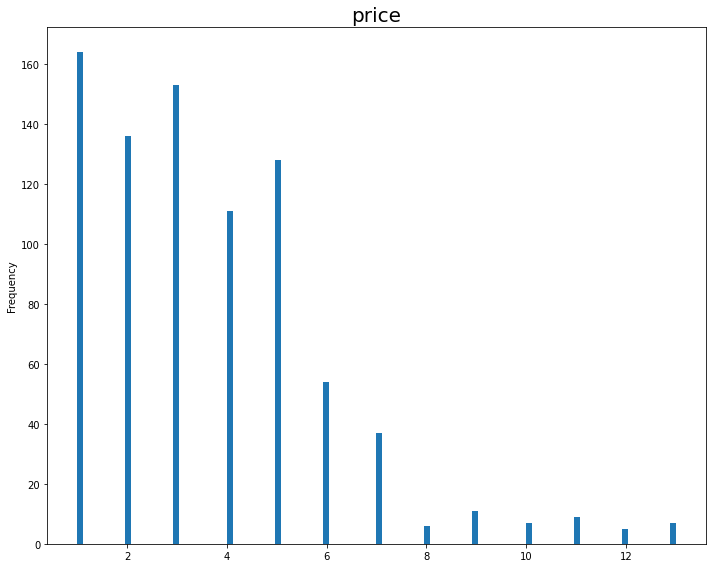

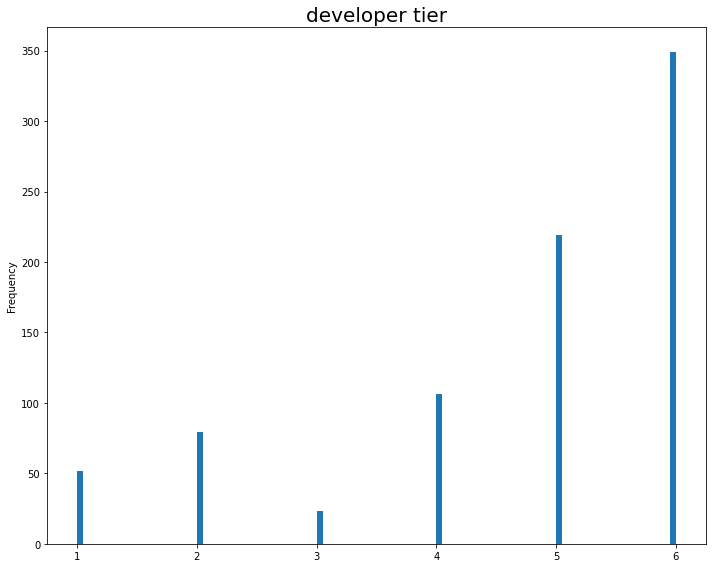

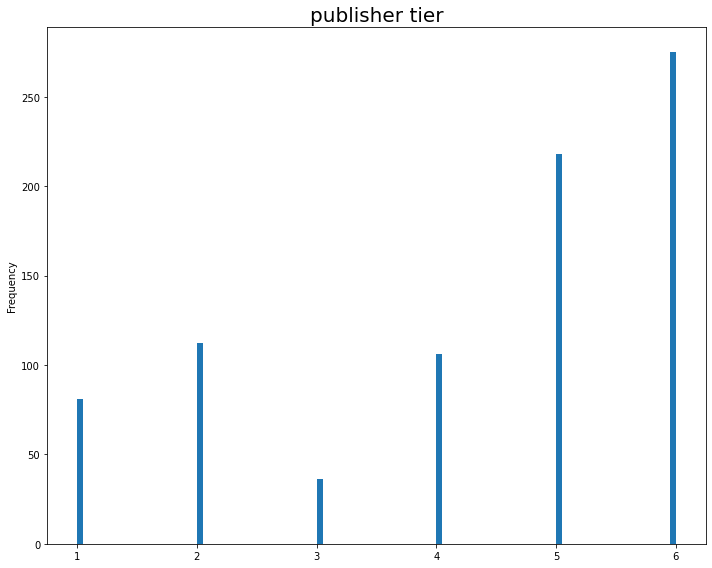

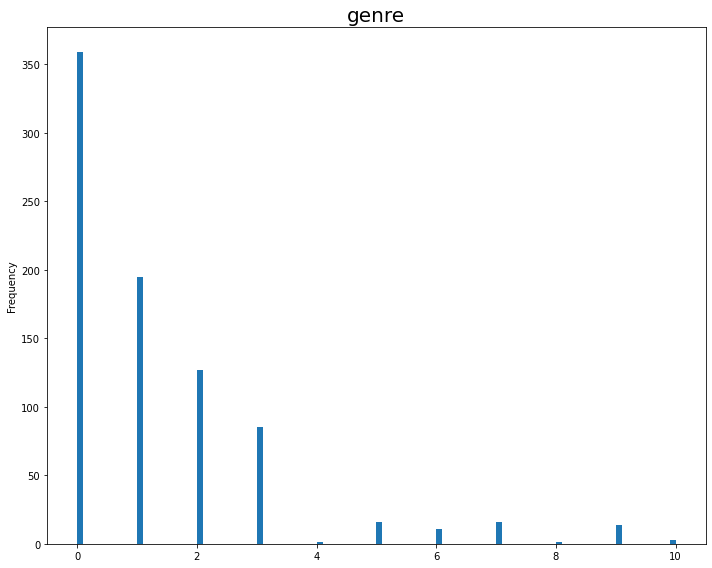

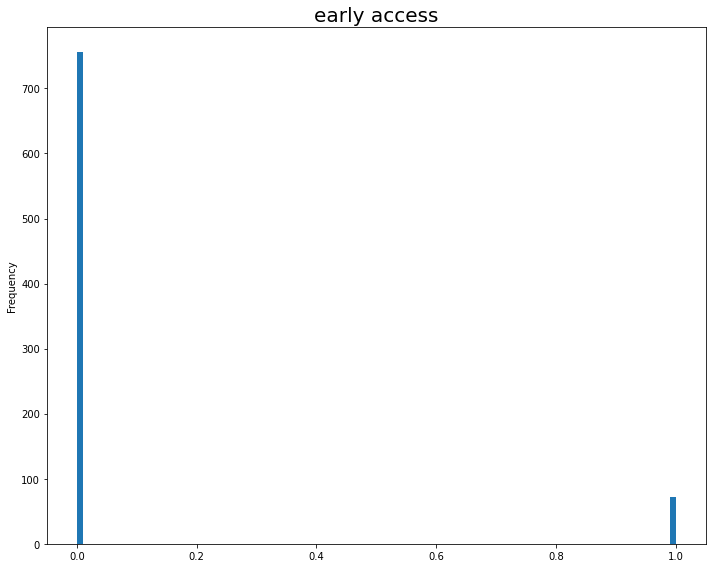

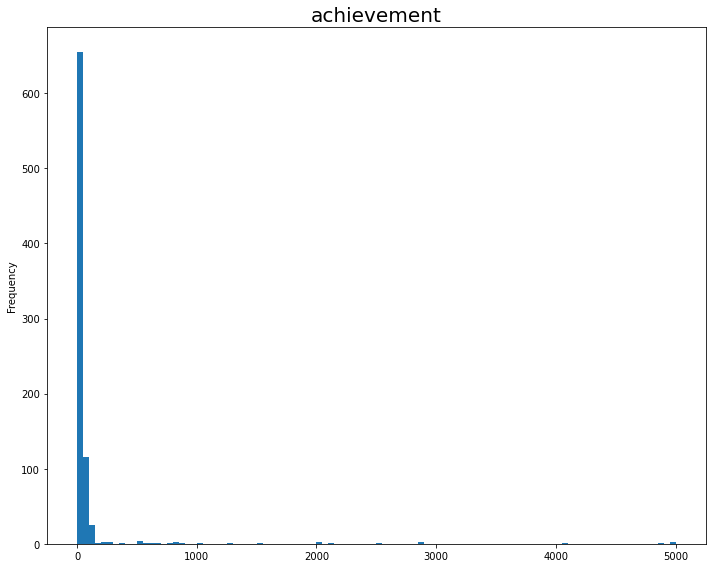

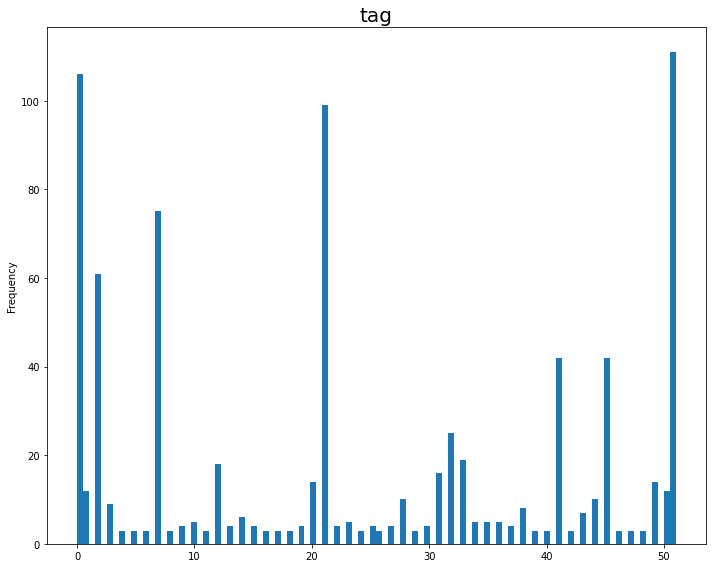

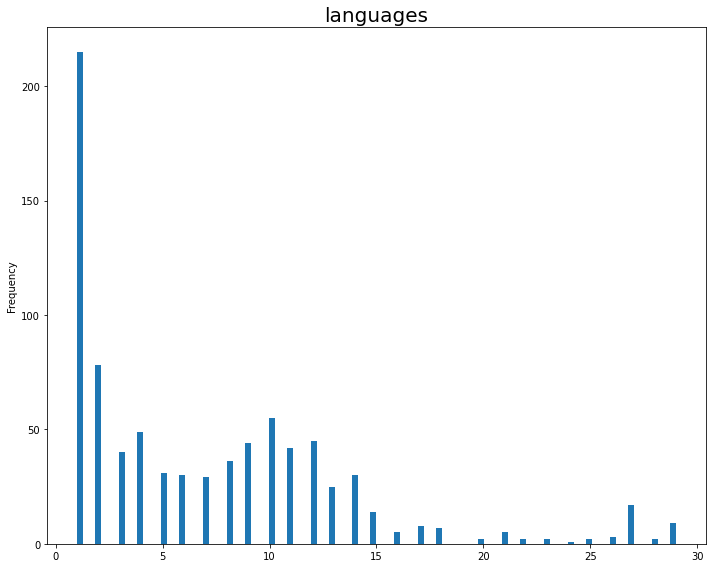

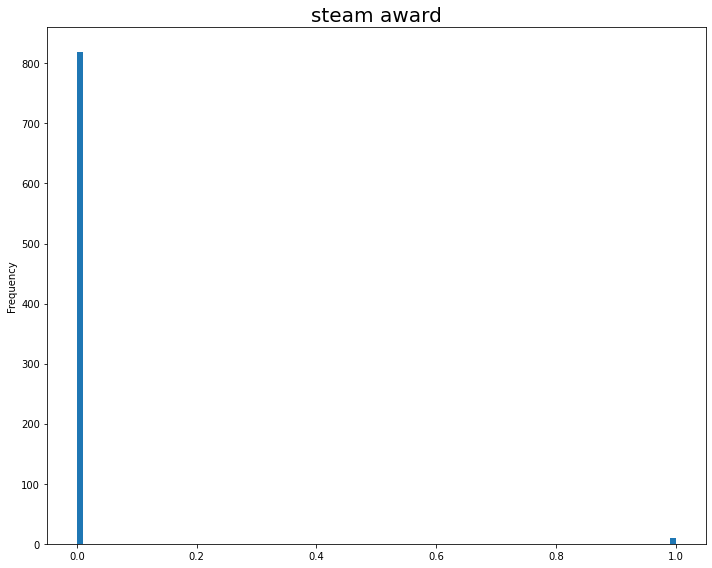

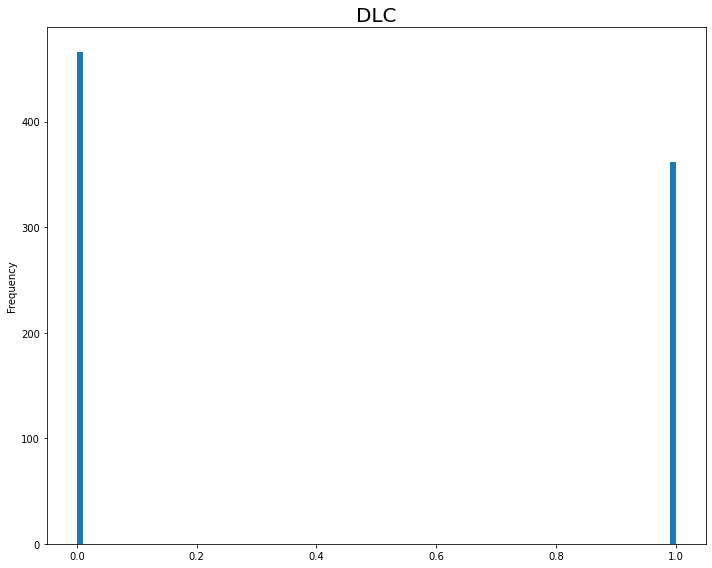

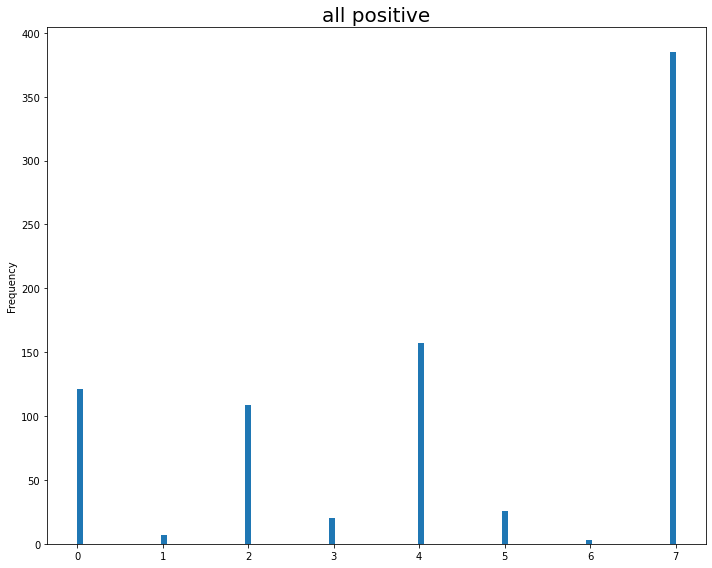

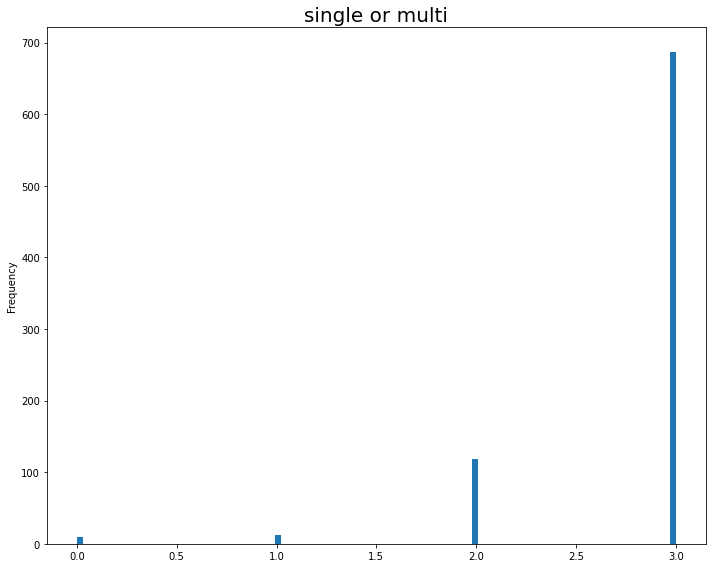

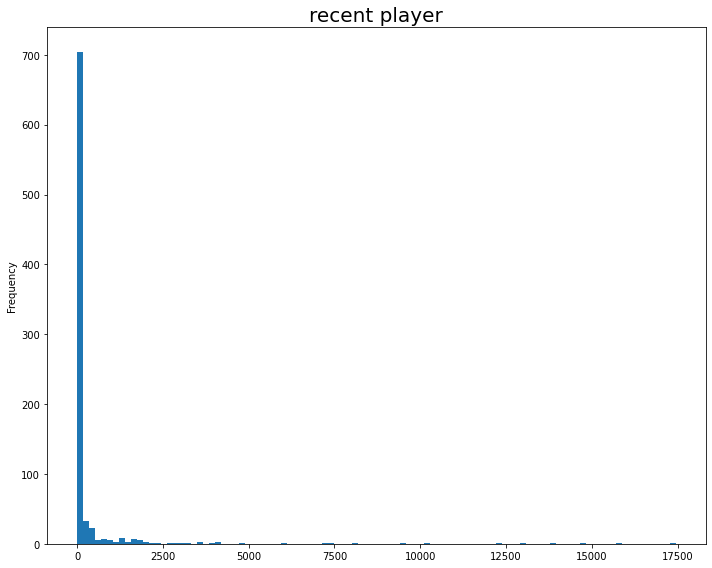

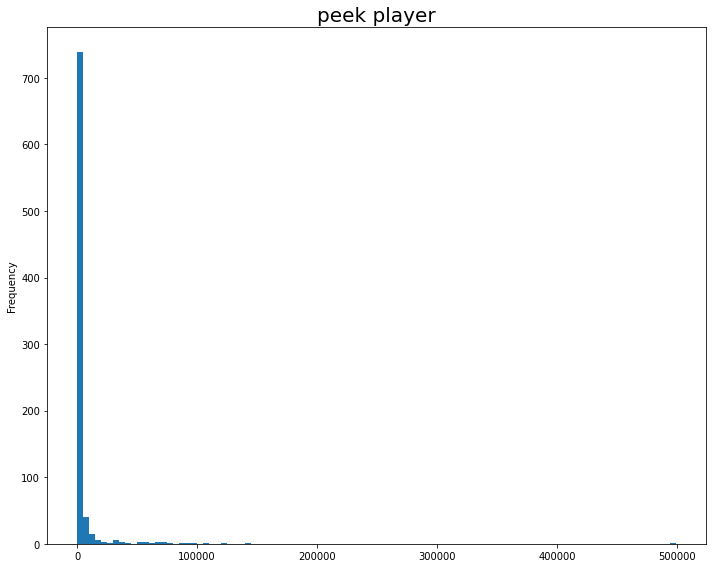

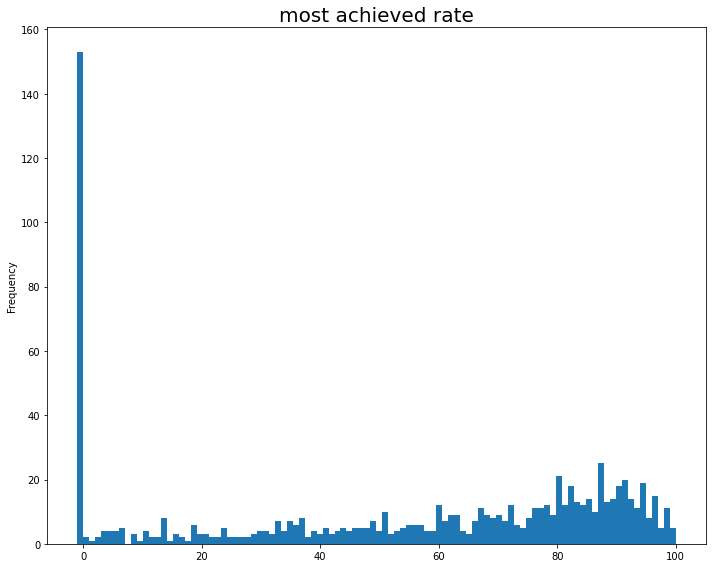

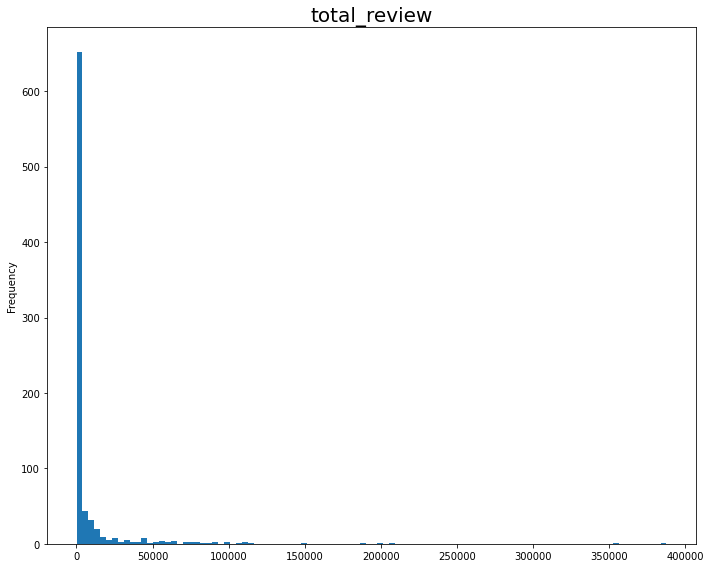

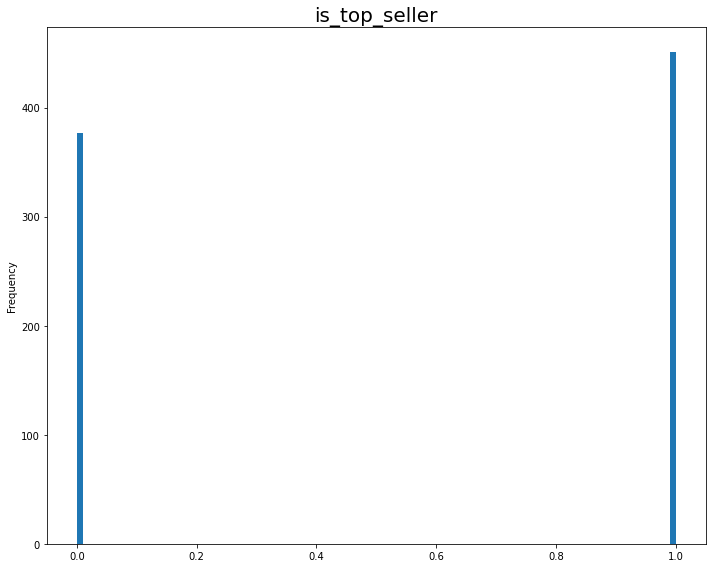

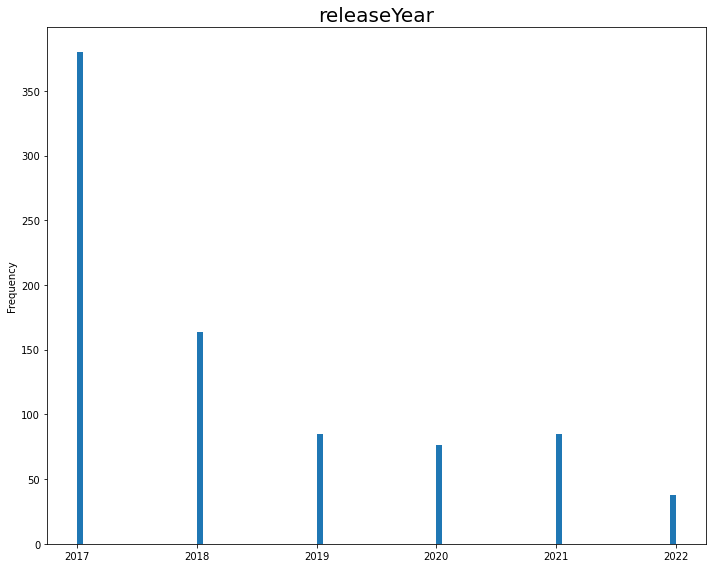

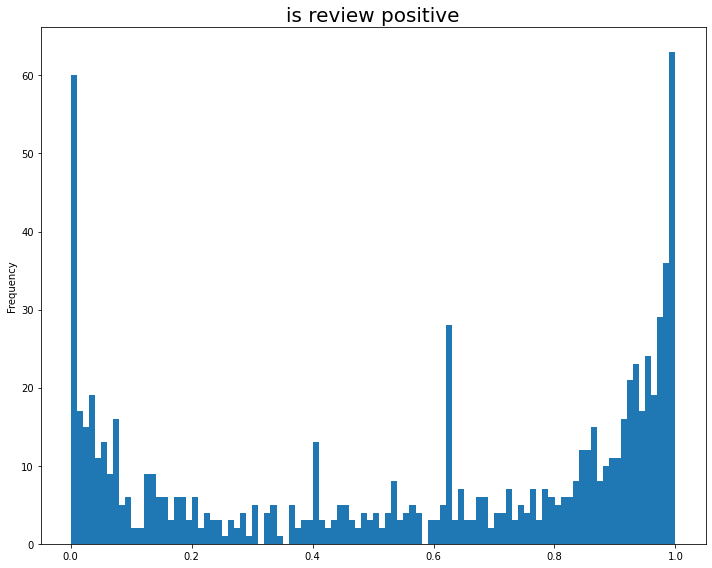

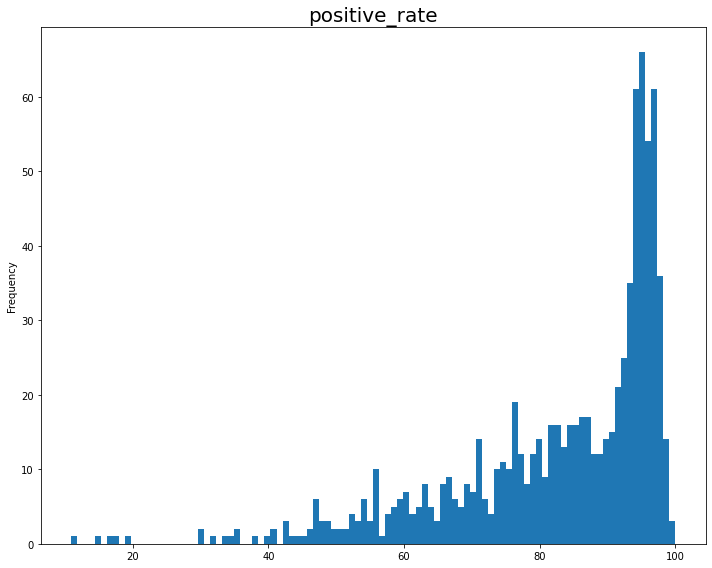

In [16]:
import matplotlib.pyplot as plt

for col in data.columns:
    tp = data[col].dtypes
    plt.figure(figsize=(10, 8))
    data[col].plot(kind='hist', bins=100)
    plt.title(col, fontdict={"fontsize":20})
    plt.tight_layout()
    plt.show()

In [17]:
data.loc[data['is_top_seller'] == 0, 'is_top_seller'].count(), data.loc[data['is_top_seller'] == 1, 'is_top_seller'].count()

(377, 451)

## 데이터 분리
---
- 대조군 : `['price', 'developer tier', 'publisher tier', 'genre', 'early access', 'achievement', 'tag', 'languages', 'DLC', 'single or multi', 'releaseYear']`

- 실험군 : `['price', 'developer tier', 'publisher tier', 'genre', 'early access', 'achievement', 'tag', 'languages', 'steam award', 'DLC', 'all positive', 'single or multi', 'recent player', 'peek player', 'most achieved rate', 'releaseYear', 'is review positive', 'total_review', 'positive_rate'']`

- 대조군에 포함되지 않는 속성 : `['steam award', 'all positive', 'recent player', 'peek player', 'most achieved rate', 'is review positive', 'positive_rate', 'total_review']`

In [ ]:
import copy

con_data = copy.deepcopy(data)  # 대조군
exp_data = copy.deepcopy(data)  # 실험군

not_con = ['steam award', 'all positive', 'recent player', 'peek player', 'most achieved rate', 'is review positive', 'positive_rate', 'total_review']
con_data = con_data.drop(not_con, axis=1)
con_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 828 entries, 0 to 827
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            828 non-null    float64
 1   developer tier   828 non-null    float64
 2   publisher tier   828 non-null    float64
 3   genre            828 non-null    int64  
 4   early access     828 non-null    float64
 5   achievement      828 non-null    float64
 6   tag              828 non-null    int64  
 7   languages        828 non-null    float64
 8   DLC              828 non-null    float64
 9   single or multi  828 non-null    int64  
 10  is_top_seller    828 non-null    int64  
 11  releaseYear      828 non-null    int64  
dtypes: float64(7), int64(5)
memory usage: 84.1 KB


In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split as ttsp
import imblearn  # 샘플링 관련 라이브러리
# under-sampling
# 참고 https://dining-developer.tistory.com/27
from imblearn.under_sampling import RandomUnderSampler
print("\nimblearn 버전 확인\n{}".format(imblearn.__version__))

con_x = con_data.drop('is_top_seller', axis=1).values
con_y = con_data["is_top_seller"].values

exp_x = exp_data.drop('is_top_seller', axis=1).values
exp_y = exp_data["is_top_seller"].values

con_x, con_y = RandomUnderSampler(random_state=seed).fit_resample(con_x, con_y)
exp_x, exp_y = RandomUnderSampler(random_state=seed).fit_resample(exp_x, exp_y)

con_x_tr, con_x_te, con_y_tr, con_y_te = ttsp(con_x, con_y, test_size=0.2, random_state=seed)

exp_x_tr, exp_x_te, exp_y_tr, exp_y_te = ttsp(exp_x, exp_y, test_size=0.2, random_state=seed)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)


imblearn 버전 확인
0.8.1


## build model

In [ ]:
import os
import tensorflow as tf
from keras.callbacks import EarlyStopping, ModelCheckpoint

MODEL_DIR = '/content/drive/MyDrive/Colab Notebooks/model/'
if not os.path.exists(MODEL_DIR):
    os.mkdir(MODEL_DIR)

epoch = 300
batch = 10

con_DNN_acc_list = []
con_DNN_loss_list = []

In [ ]:
con_modelpath = MODEL_DIR+"con_best_model.hdf5"
con_chpt = ModelCheckpoint(filepath=con_modelpath, monitor='val_loss', verbose=1, save_best_only=True)
i = 1

for tr, te in skf.split(con_x, con_y):
    print(f"\nsplit #{i} start\n")
    con_escb = EarlyStopping(monitor='val_loss', patience=max(int(epoch * 0.1), 5))
    
    con_model = tf.keras.Sequential([
        # tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Dense(1024, activation="relu"),
        # tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    con_model.compile(optimizer='adam', loss='mae', metrics=['accuracy'])
    con_hstr = con_model.fit(con_x[tr], con_y[tr], epochs=epoch, validation_data=(con_x[te], con_y[te]), batch_size=batch, callbacks=[con_chpt, con_escb])
    print(f"\nsplit #{i} summary\n")
    con_model.summary()
    eval_loss, eval_acc = con_model.evaluate(con_x_te, con_y_te)
    con_DNN_loss_list.append(eval_loss)
    con_DNN_acc_list.append(eval_acc)
    i += 1
    print()


split #1 start

Epoch 1/300
53/68 [======================>.......] - ETA: 0s - loss: 0.5007 - accuracy: 0.5000
Epoch 1: val_loss improved from inf to 0.49938, saving model to /content/drive/MyDrive/Colab Notebooks/model/con_best_model.hdf5
68/68 [==============================] - 2s 13ms/step - loss: 0.5018 - accuracy: 0.4912 - val_loss: 0.4994 - val_accuracy: 0.5000
Epoch 2/300
66/68 [============================>.] - ETA: 0s - loss: 0.5034 - accuracy: 0.4955
Epoch 2: val_loss improved from 0.49938 to 0.49753, saving model to /content/drive/MyDrive/Colab Notebooks/model/con_best_model.hdf5
68/68 [==============================] - 0s 5ms/step - loss: 0.5037 - accuracy: 0.4926 - val_loss: 0.4975 - val_accuracy: 0.5000
Epoch 3/300
59/68 [=========================>....] - ETA: 0s - loss: 0.5023 - accuracy: 0.4746
Epoch 3: val_loss improved from 0.49753 to 0.49278, saving model to /content/drive/MyDrive/Colab Notebooks/model/con_best_model.hdf5
68/68 [==============================] - 0s 

In [ ]:
cDNNloss = np.array(con_DNN_loss_list)
cDNNacc = np.array(con_DNN_acc_list)
print(f"loss mean : {cDNNloss.mean():.4f}")
print(f"acc mean : {cDNNacc.mean():.4f}")

loss mean : 0.3293
acc mean : 0.6709


In [ ]:
exp_DNN_loss_list = []
exp_DNN_acc_list = []

exp_modelpath = MODEL_DIR+"exp_best_model.hdf5"

i = 1

for tr, te in skf.split(exp_x, exp_y):
    print(f"\nsplit #{i} start\n")
    exp_chpt = ModelCheckpoint(filepath=exp_modelpath, monitor='val_loss', verbose=1, save_best_only=True)
    exp_escb = EarlyStopping(monitor='val_loss', patience=max(int(epoch * 0.1), 5))

    exp_model = tf.keras.Sequential([
        # tf.keras.layers.Dense(512, activation="relu"),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.BatchNormalization(),
        # tf.keras.layers.Dense(1024, activation="relu"),
        # tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    exp_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    exp_hstr = exp_model.fit(exp_x[tr], exp_y[tr], epochs=epoch, validation_data=(exp_x[te], exp_y[te]), batch_size=batch, callbacks=[exp_chpt, exp_escb])
    print(f"\nsplit #{i} summary\n")
    exp_model.summary()
    eval_loss, eval_acc = exp_model.evaluate(exp_x_te, exp_y_te)
    exp_DNN_loss_list.append(eval_loss)
    exp_DNN_acc_list.append(eval_acc)
    i += 1
    print()

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
68/68 [==============================] - 0s 3ms/step - loss: 0.2018 - accuracy: 0.9204 - val_loss: 0.1889 - val_accuracy: 0.9211
Epoch 133/300
64/68 [===========================>..] - ETA: 0s - loss: 0.1692 - accuracy: 0.9344
Epoch 133: val_loss improved from 0.17168 to 0.16720, saving model to /content/drive/MyDrive/Colab Notebooks/model/exp_best_model.hdf5
68/68 [==============================] - 0s 4ms/step - loss: 0.1764 - accuracy: 0.9336 - val_loss: 0.1672 - val_accuracy: 0.9211
Epoch 134/300
58/68 [========================>.....] - ETA: 0s - loss: 0.1774 - accuracy: 0.9310
Epoch 134: val_loss did not improve from 0.16720
68/68 [==============================] - 0s 3ms/step - loss: 0.1818 - accuracy: 0.9292 - val_loss: 0.1721 - val_accuracy: 0.9211
Epoch 135/300
60/68 [=========================>....] - ETA: 0s - loss: 0.1997 - accuracy: 0.9400
Epoch 135: val_loss did not improve from 0.16720
68/68 [==============================] - 0s 3ms/step 

In [ ]:
eDNNloss = np.array(exp_DNN_loss_list)
eDNNacc = np.array(exp_DNN_acc_list)
print(f"loss mean : {eDNNloss.mean():.4f}")
print(f"acc mean : {eDNNacc.mean():.4f}")

loss mean : 0.2523
acc mean : 0.9007


## evaluate model

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import load_model

def draw_scatter(oput, y_te):
    # res = []
    # for i in range(oput.shape[0]):
    #     m = 0
    #     try:
    #         for j in range(1, oput.shape[1]):
    #             if oput[i][j] > oput[i][m]:
    #                 m = j
    #         res.append(m)
    #     except IndexError:
    #         break
    # if len(res) == len(y_te):
    #     oput = res

    sns.set(rc={'figure.figsize':(16, 5)})
    sns.set_style("ticks")

    plt.figure(figsize=(16, 5))
    plt.scatter(range(len(y_te)), y_te, c="blue", marker='o', alpha=0.7, label='y_test')
    plt.scatter(range(len(y_te)), oput, c="magenta", marker='x', alpha=0.7, label='y_pred')
    plt.legend(loc='lower right')
    plt.grid()
    plt.xlabel('range(len(y_tr))', fontdict={"fontsize":15})
    plt.ylabel('y and pred_y', fontdict={"fontsize":15})
    plt.title('scatter y and pred_y', fontdict={"fontsize":20})
    plt.show()

def load_and_evaluate_model(model_path, model_history, x_tr, y_tr, x_te, y_te):
    model = load_model(model_path)
    *_, loss, acc = model.evaluate(x_te, y_te)
    oput = model.predict(x_te)
    
    print("evaluate model")
    print("loss : {:.4f}\nacc : {:.4f}".format(loss, acc))

    sns.set(rc={'figure.figsize':(16, 5)})
    sns.set_style("ticks")

    draw_scatter(oput, y_te)

    loss = model_history.history["loss"]
    acc = model_history.history["accuracy"]
    val_loss = model_history.history["val_loss"]
    val_acc = model_history.history["val_accuracy"]
    x_len = range(1, len(loss) + 1)  # epoch

    plt.plot(x_len, loss, c="blue", label='loss')
    plt.plot(x_len, val_loss, c="magenta", label='val_loss')
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('epoch', fontdict={"fontsize":15})
    plt.ylabel('loss', fontdict={"fontsize":15})
    plt.title('loss', fontdict={"fontsize":20})
    plt.show()

    plt.plot(x_len, acc, c="blue", label='acc')
    plt.plot(x_len, val_acc, c="magenta", label='val_acc')
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('epoch', fontdict={"fontsize":15})
    plt.ylabel('acc', fontdict={"fontsize":15})
    plt.title('acc', fontdict={"fontsize":20})
    plt.show()

5/5 [==============================] - 0s 3ms/step - loss: 0.3086 - accuracy: 0.6954
evaluate model
loss : 0.3086
acc : 0.6954


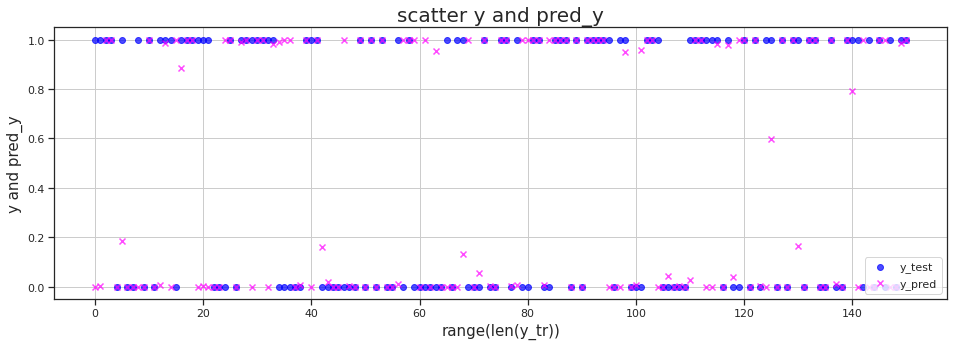

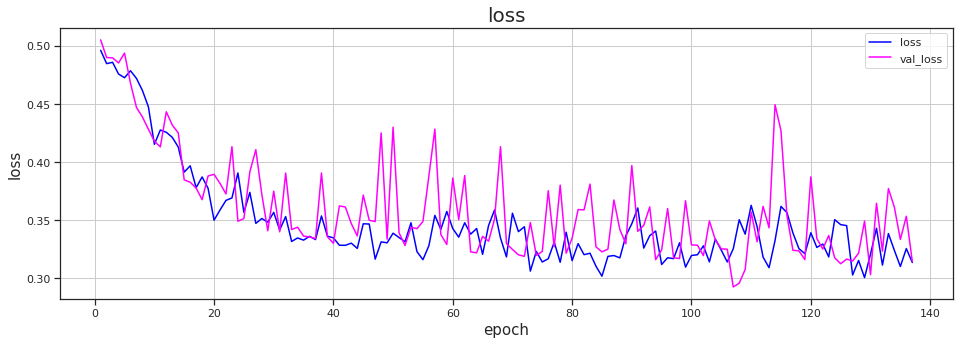

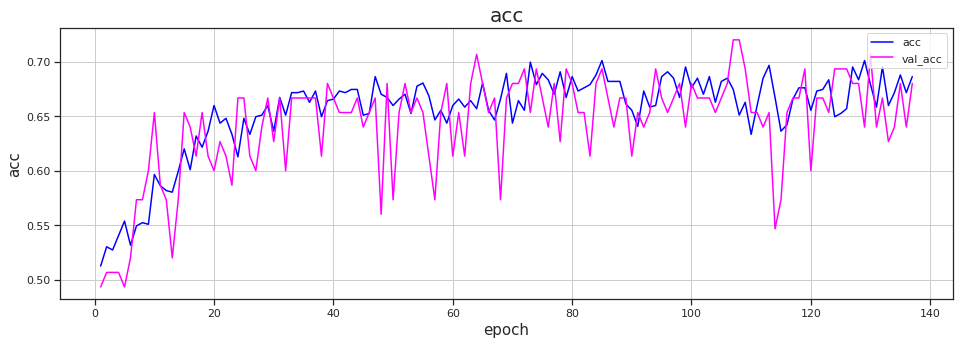

In [ ]:
load_and_evaluate_model(con_modelpath, con_hstr, con_x_tr, con_y_tr, con_x_te, con_y_te)

5/5 [==============================] - 0s 3ms/step - loss: 0.2677 - accuracy: 0.8742
evaluate model
loss : 0.2677
acc : 0.8742


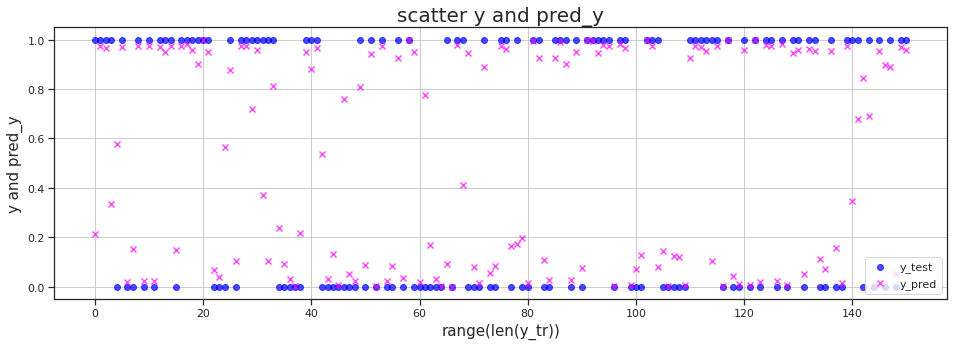

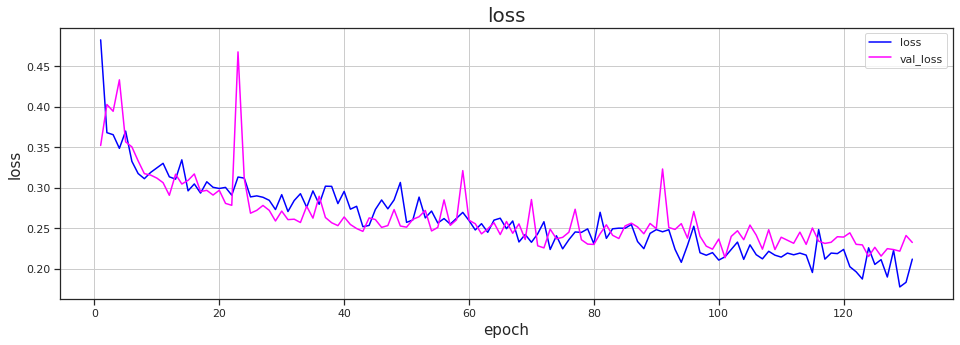

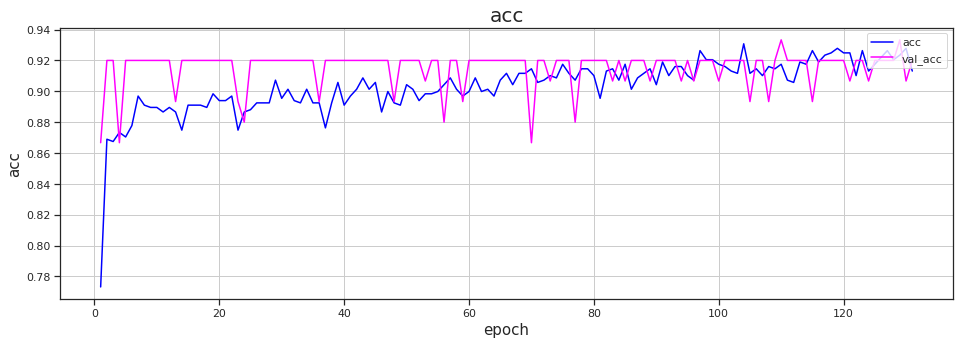

In [ ]:
load_and_evaluate_model(exp_modelpath, exp_hstr, exp_x_tr, exp_y_tr, exp_x_te, exp_y_te)

In [ ]:
def draw_accs(acc):
    x = np.arange(len(acc))
    y = acc

    plt.bar(x, y, color="blue", label='acc', align='center', alpha=0.7)
    plt.ylim(0, 1.0)
    plt.legend(loc='upper right')
    plt.grid()
    plt.xlabel('K-fold', fontdict={"fontsize":15})
    plt.ylabel('acc', fontdict={"fontsize":15})
    plt.title('acc', fontdict={"fontsize":20})
    plt.show()

Accuracy: 0.7330
Standard Deviation: 0.0569


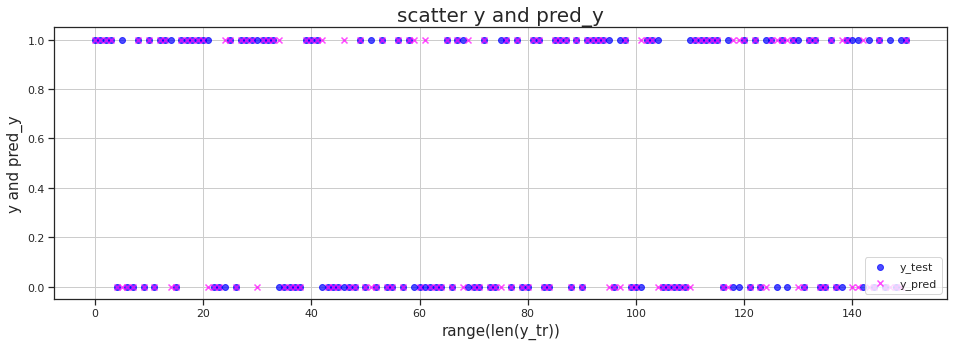

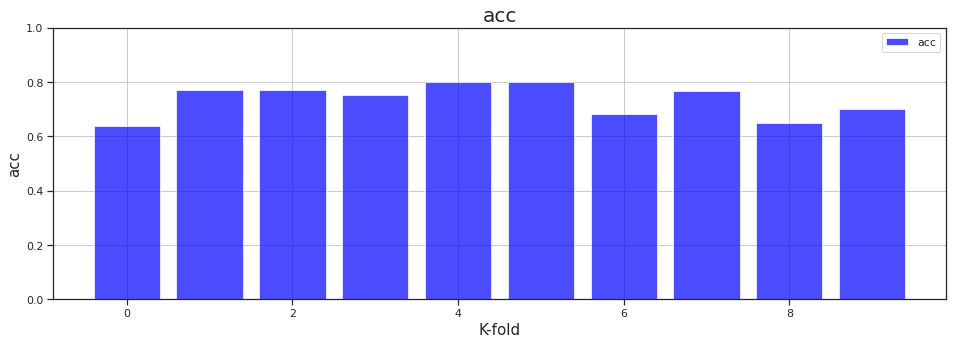


Accuracy: 0.9767
Standard Deviation: 0.0153


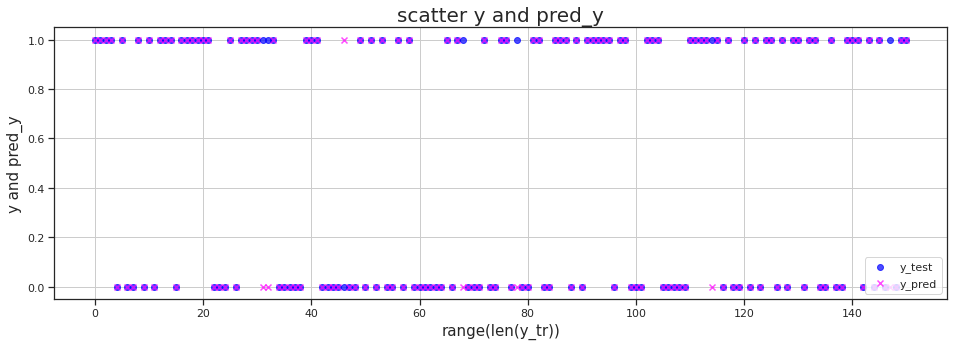

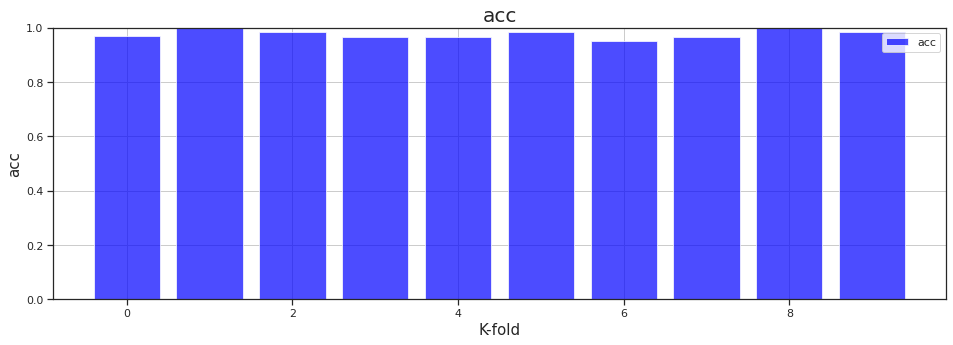

In [ ]:
# con_x, con_y
# exp_x, exp_y
# con_x_tr, con_x_te, con_y_tr, con_y_te
# exp_x_tr, exp_x_te, exp_y_tr, exp_y_te

# 랜덤 포레스트 분류기를 불러 옵니다.
from sklearn.ensemble import RandomForestClassifier

# 학습 환경을 설정합니다.
con_classifier= RandomForestClassifier()
con_classifier.fit(con_x_tr, con_y_tr)

exp_classifier= RandomForestClassifier()
exp_classifier.fit(exp_x_tr, exp_y_tr)
 
# 테스트셋에 적용합니다. 
y_con_pred = con_classifier.predict(con_x_te)
y_exp_pred = exp_classifier.predict(exp_x_te)

# 계층별 교차 검증 환경을 설정합니다. 
skf=StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산합니다. 
con_accuracies = cross_val_score(estimator = con_classifier, X = con_x_tr, y = con_y_tr, cv = skf)
exp_accuracies = cross_val_score(estimator = exp_classifier, X = exp_x_tr, y = exp_y_tr, cv = skf)

# 정확도와 표준편차를 출력합니다. 
print("Accuracy: {:.4f}".format(con_accuracies.mean()))
print("Standard Deviation: {:.4f}".format(con_accuracies.std()))
draw_scatter(y_con_pred, con_y_te)
draw_accs(con_accuracies)

print()

print("Accuracy: {:.4f}".format(exp_accuracies.mean()))
print("Standard Deviation: {:.4f}".format(exp_accuracies.std()))
draw_scatter(y_exp_pred, exp_y_te)
draw_accs(exp_accuracies)

Accuracy: 0.7563
Standard Deviation: 0.0519


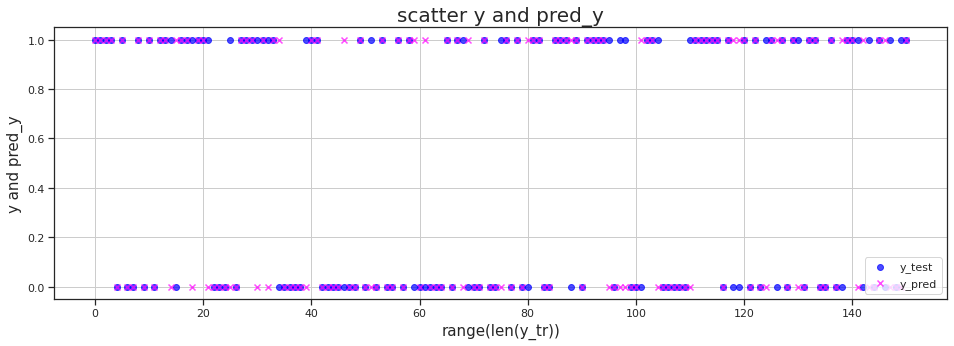

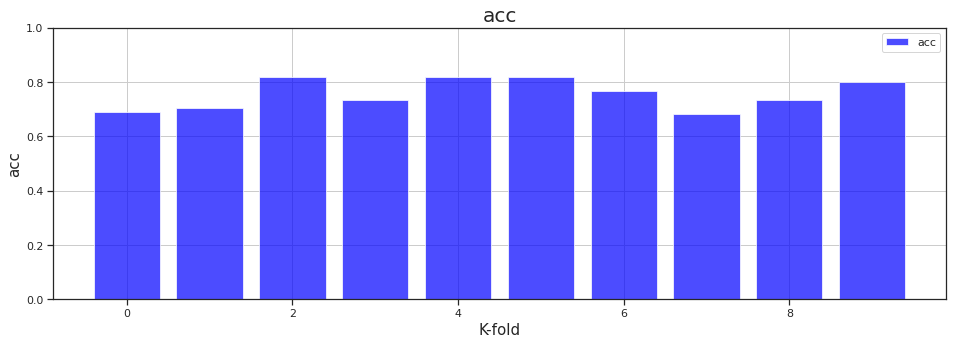


Accuracy: 0.9767
Standard Deviation: 0.0226


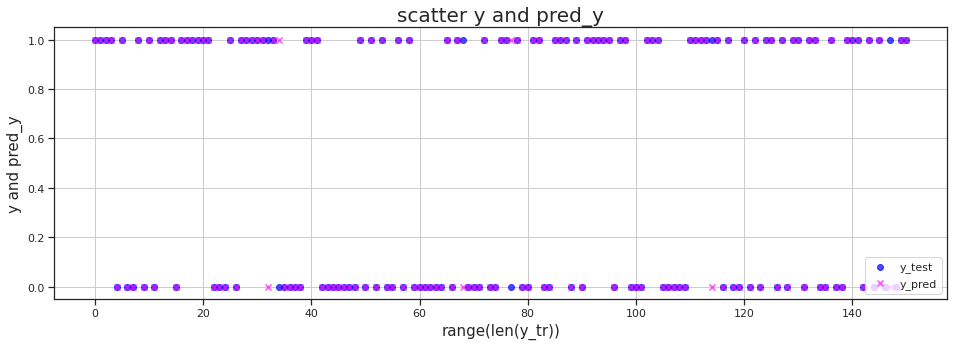

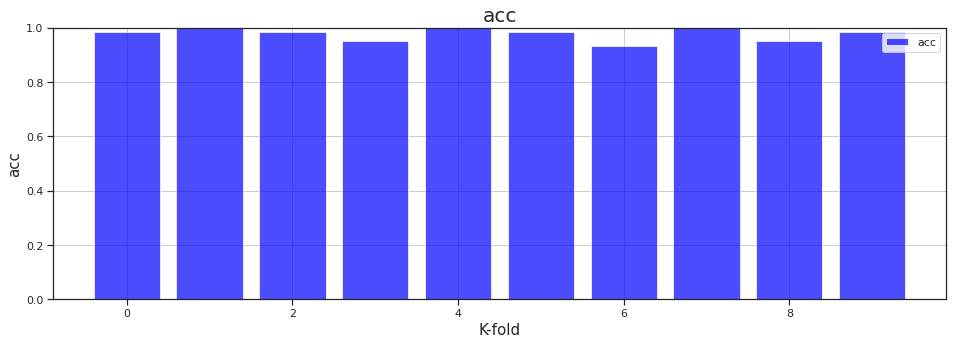

In [ ]:
# con_x, con_y
# exp_x, exp_y
# con_x_tr, con_x_te, con_y_tr, con_y_te
# exp_x_tr, exp_x_te, exp_y_tr, exp_y_te

# 에이다 부스트 분류기를 불러옵니다.
from sklearn.ensemble import AdaBoostClassifier

# 학습 환경을 설정합니다.
con_classifier = AdaBoostClassifier(n_estimators=100)
con_classifier.fit(con_x_tr, con_y_tr)

exp_classifier = AdaBoostClassifier(n_estimators=100)
exp_classifier.fit(exp_x_tr, exp_y_tr)
 
# 테스트셋에 적용합니다. 
y_con_pred = con_classifier.predict(con_x_te)
y_exp_pred = exp_classifier.predict(exp_x_te)

# 계층별 교차 검증 환경을 설정합니다. 
skf=StratifiedKFold(n_splits=10, shuffle=True)

# 교차 검증을 통해 정확도를 계산합니다. 
con_accuracies = cross_val_score(estimator = con_classifier, X = con_x_tr, y = con_y_tr, cv = skf)
exp_accuracies = cross_val_score(estimator = exp_classifier, X = exp_x_tr, y = exp_y_tr, cv = skf)

# 정확도와 표준편차를 출력합니다. 
print("Accuracy: {:.4f}".format(con_accuracies.mean()))
print("Standard Deviation: {:.4f}".format(con_accuracies.std()))
draw_scatter(y_con_pred, con_y_te)
draw_accs(con_accuracies)

print()

print("Accuracy: {:.4f}".format(exp_accuracies.mean()))
print("Standard Deviation: {:.4f}".format(exp_accuracies.std()))
draw_scatter(y_exp_pred, exp_y_te)
draw_accs(exp_accuracies)